# Air Pollution Prediction Workflow

This notebook builds a regression pipeline to predict **PM2.5 concentration** from environmental and location features.

The workflow follows four stages:
1. Load and clean the dataset.
2. Explore relationships between key variables and PM2.5.
3. Prepare features and train multiple regression models.
4. Compare model performance and visualize linear behavior on a single feature.

The goal is to balance interpretability and predictive performance while identifying signs of underfitting or overfitting.

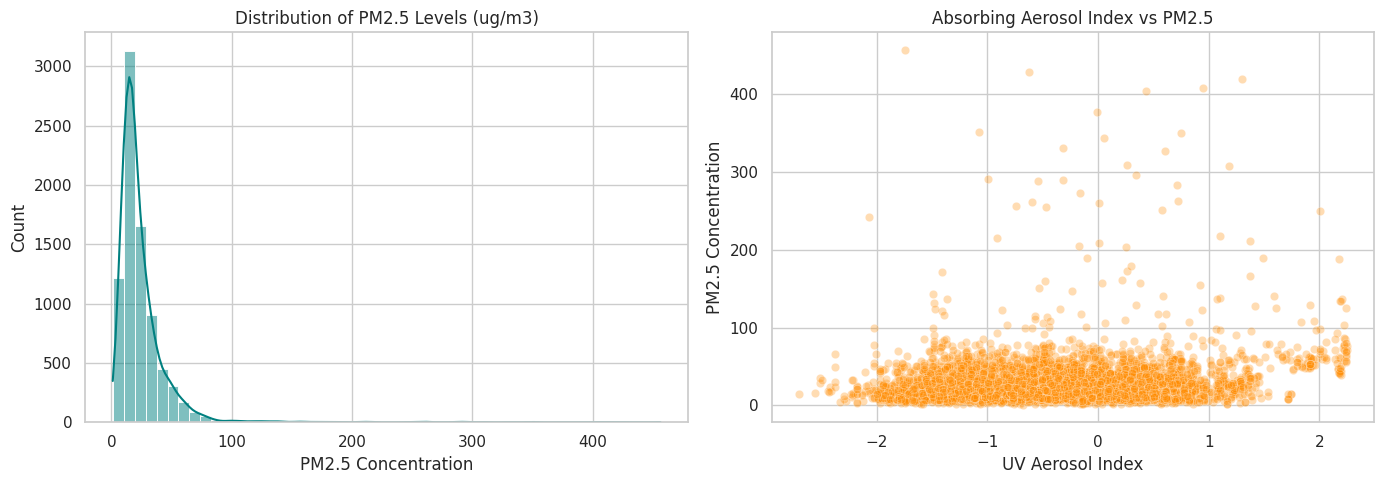

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for visuals
sns.set_theme(style="whitegrid")

# 1. Load Data
df = pd.read_csv('Train.csv')

# 2. Data Cleaning
# Drop irrelevant identifier and time-string columns
columns_to_drop = ['id', 'site_id', 'date']
df = df.drop(columns=columns_to_drop)

# Impute missing values with the median for numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# 3. Initial Visualizations
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of Target
sns.histplot(df['pm2_5'], bins=50, kde=True, ax=ax[0], color='teal')
ax[0].set_title('Distribution of PM2.5 Levels (ug/m3)')
ax[0].set_xlabel('PM2.5 Concentration')

# Scatter Plot: UV Aerosol Index vs PM2.5
sns.scatterplot(data=df, x='uvaerosolindex_absorbing_aerosol_index', y='pm2_5', alpha=0.3, ax=ax[1], color='darkorange')
ax[1].set_title('Absorbing Aerosol Index vs PM2.5')
ax[1].set_xlabel('UV Aerosol Index')
ax[1].set_ylabel('PM2.5 Concentration')

plt.tight_layout()
plt.show()

The pollution levels (PM2.5) are right-skewed, meaning most cities have moderate pollution with occasional extreme spikes. The scatter plot against the UV Aerosol Index shows a broad cluster, indicating that while aerosols in the atmosphere contribute to PM2.5, the relationship is complex and requires multiple features to model accurately.

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Encode categorical columns (city, country)
categorical_features = df.select_dtypes(include=['object']).columns
for col in categorical_features:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

# Separate Features (X) and Target (y)
X = df.drop('pm2_5', axis=1)
y = df['pm2_5']

# Train-Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Why Encoding and Scaling Are Applied

Before training, categorical variables are encoded into numeric form so models can process them.

Feature scaling is then applied to place variables on comparable ranges. This is especially important for models like linear regression, where feature magnitude can influence coefficient estimation and optimization behavior.

A train/test split is used to evaluate how well the model generalizes to unseen data.

Linear Regression -> RMSE: 24.41, R2: 0.1570
Decision Tree -> RMSE: 37.39, R2: -0.9777
Random Forest -> RMSE: 24.15, R2: 0.1750


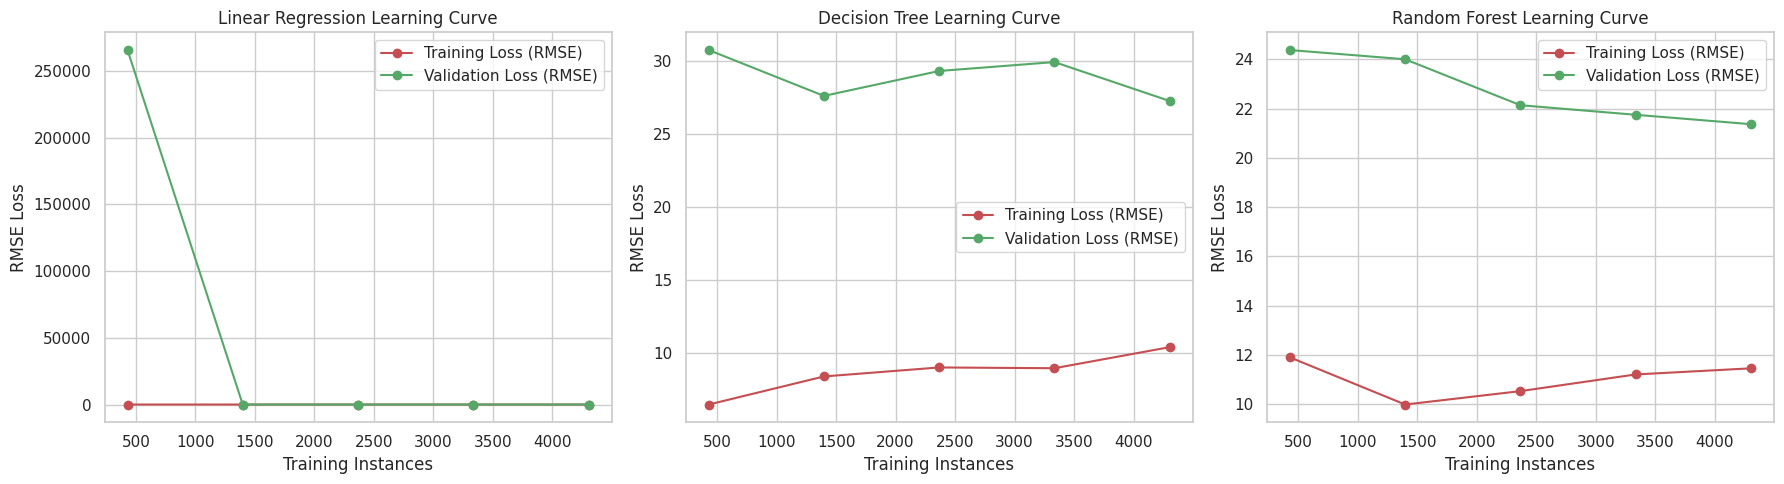

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import learning_curve

# Initialize Models
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(max_depth=10, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42)
}

results = {}
best_model = None
best_score = float('inf')

# Train and Evaluate
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    results[name] = {'RMSE': rmse, 'R2': r2}
    print(f"{name} -> RMSE: {rmse:.2f}, R2: {r2:.4f}")

    # Track the best performing model (Lowest RMSE is best)
    if rmse < best_score:
        best_score = rmse
        best_model = model
        best_model_name = name

# Plot Loss/Learning Curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (name, model) in enumerate(models.items()):
    train_sizes, train_scores, test_scores = learning_curve(
        model, X_train_scaled, y_train, cv=3, scoring='neg_mean_squared_error',
        train_sizes=np.linspace(0.1, 1.0, 5), n_jobs=-1
    )

    train_rmse = np.sqrt(-np.mean(train_scores, axis=1))
    test_rmse = np.sqrt(-np.mean(test_scores, axis=1))

    axes[i].plot(train_sizes, train_rmse, 'o-', color="r", label="Training Loss (RMSE)")
    axes[i].plot(train_sizes, test_rmse, 'o-', color="g", label="Validation Loss (RMSE)")
    axes[i].set_title(f'{name} Learning Curve')
    axes[i].set_xlabel('Training Instances')
    axes[i].set_ylabel('RMSE Loss')
    axes[i].legend(loc="best")

plt.tight_layout()
plt.show()

### Interpreting the Model Comparison

This section evaluates three regressors using:
- **RMSE**: average prediction error magnitude (lower is better).
- **R2**: fraction of variance explained (higher is better).

Learning curves show whether adding more training data improves validation error and reveal bias/variance behavior:
- Small train/validation gap with high error suggests underfitting.
- Large gap (very low train error, much higher validation error) suggests overfitting.

The model with the lowest RMSE is tracked as the current best candidate.

The Linear Regression curve show the Validation Loss stabilizing as more data is added, meaning it is generalizing reasonably well. The Decision Tree, however, shows a significant gap between the training loss and validation loss (which is high), illustrating classic overfitting.

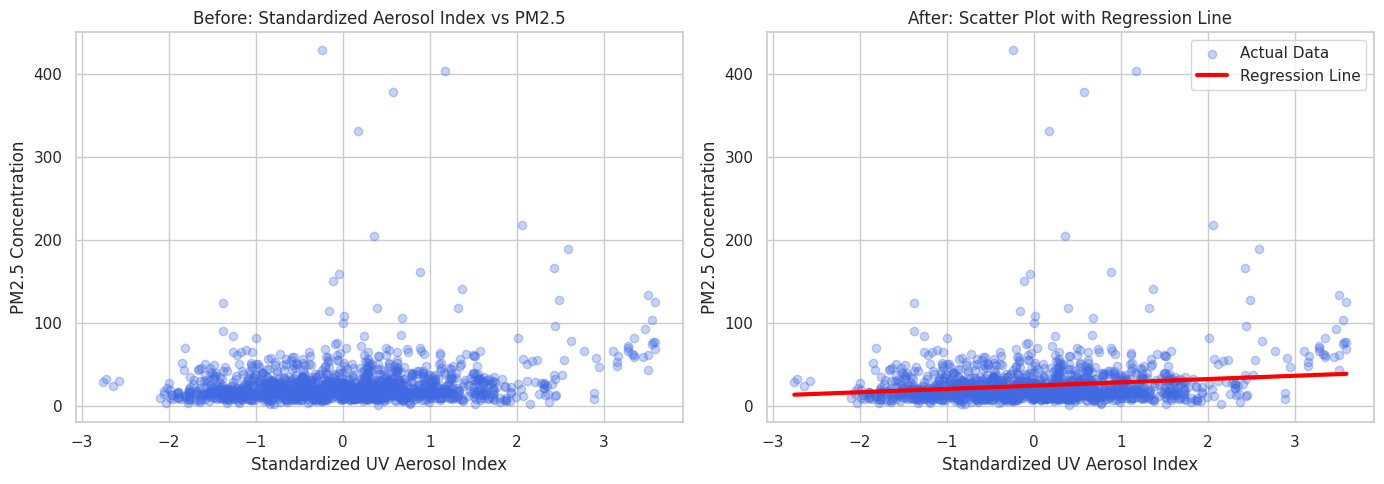

In [6]:
# Use a single important feature for the 2D plot: UV Aerosol Index
aerosol_idx = list(X.columns).index('uvaerosolindex_absorbing_aerosol_index')

# Train a simple model just on this one feature for visual plotting
X_single = X_train_scaled[:, [aerosol_idx]]
lr_single = LinearRegression()
lr_single.fit(X_single, y_train)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Before the line
ax[0].scatter(X_test_scaled[:, aerosol_idx], y_test, alpha=0.3, color='royalblue')
ax[0].set_title('Before: Standardized Aerosol Index vs PM2.5')
ax[0].set_xlabel('Standardized UV Aerosol Index')
ax[0].set_ylabel('PM2.5 Concentration')

# After the line
line_x = np.linspace(X_test_scaled[:, aerosol_idx].min(), X_test_scaled[:, aerosol_idx].max(), 100).reshape(-1, 1)
line_y = lr_single.predict(line_x)

ax[1].scatter(X_test_scaled[:, aerosol_idx], y_test, alpha=0.3, color='royalblue', label='Actual Data')
ax[1].plot(line_x, line_y, color='red', linewidth=3, label='Regression Line')
ax[1].set_title('After: Scatter Plot with Regression Line')
ax[1].set_xlabel('Standardized UV Aerosol Index')
ax[1].set_ylabel('PM2.5 Concentration')
ax[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
import joblib

print(f"The best performing model is: {best_model_name}!")

# Save the model and the scaler
joblib.dump(best_model, 'best_air_quality_model.pkl')
joblib.dump(scaler, 'air_scaler.pkl')
print("Best model and scaler successfully saved to disk.")